In [3]:
import pandas as pd
import sqlite3

orgs     = pd.read_excel('voxvertex_.xlsx', sheet_name='organizations')
bookings = pd.read_excel('voxvertex_.xlsx', sheet_name='bookings')
experts  = pd.read_excel('voxvertex_.xlsx', sheet_name='experts')
activity = pd.read_excel('voxvertex_.xlsx', sheet_name='org_activity')

conn = sqlite3.connect('voxvertex.db')

orgs.to_sql('organizations', conn, if_exists='replace', index=False)
bookings.to_sql('bookings', conn, if_exists='replace', index=False)
experts.to_sql('experts', conn, if_exists='replace', index=False)
activity.to_sql('org_activity', conn, if_exists='replace', index=False)

print("Done. Tables loaded.")

Done. Tables loaded.


In [4]:
## verificTION OF ALL 4 tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table'"
pd.read_sql(query, conn)

,name
0,organizations
1,bookings
2,experts
3,org_activity


In [5]:
# How many rows in each table?
for table in ['organizations', 'bookings', 'experts', 'org_activity']:
    result = pd.read_sql(f"SELECT COUNT(*) as rows FROM {table}", conn)
    print(f"{table}: {result['rows'][0]} rows")

organizations: 180 rows
bookings: 771 rows
experts: 320 rows
org_activity: 3426 rows


In [6]:
# What does the bookings table look like?
pd.read_sql("SELECT * FROM bookings LIMIT 5", conn)

,booking_id,org_id,expert_id,booking_date,session_date,topic,session_format,booking_status,session_rating,lead_time_days,contract_type,payment_status,audience_size
0,bkg_5000,org_1000,exp_2117,2024-05-13,2024-06-26,Sales Enablement,virtual,completed,3.3,44,automated,paid,20
1,bkg_5001,org_1000,exp_2123,2024-05-26,2024-06-01,DEI,virtual,completed,4.6,6,automated,paid,30
2,bkg_5002,org_1000,exp_2192,2024-06-28,2024-07-06,AI & Technology,virtual,cancelled_expert,NaN,8,automated,pending,25
3,bkg_5003,org_1000,exp_2302,2024-06-13,2024-07-13,Communication,virtual,completed,4.3,30,automated,paid,30
4,bkg_5004,org_1000,exp_2050,2024-06-25,2024-07-07,Sales Enablement,in-person,cancelled_org,NaN,12,automated,pending,50


In [7]:
# What's the split of booking statuses?
pd.read_sql("""
    SELECT booking_status, COUNT(*) as count
    FROM bookings
    GROUP BY booking_status
    ORDER BY count DESC
""", conn)


,booking_status,count
0,completed,551
1,cancelled_org,96
2,cancelled_expert,87
3,no_show,37


In [ ]:
# Out of 771 totoal bookings 551 Completed (71%)
# Experts cancel almost as much as org. Supply quality signal

In [8]:
retention = pd.read_sql("""
    WITH first_booking AS (
        SELECT org_id, MIN(booking_date) as first_date
        FROM bookings
        WHERE booking_status = 'completed'
        GROUP BY org_id
    ),
    second_booking AS (
        SELECT b.org_id, MIN(b.booking_date) as second_date
        FROM bookings b
        JOIN first_booking f ON b.org_id = f.org_id
        WHERE b.booking_status = 'completed'
        AND b.booking_date > f.first_date
        GROUP BY b.org_id
    )
    SELECT 
        f.org_id,
        f.first_date,
        s.second_date,
        JULIANDAY(s.second_date) - JULIANDAY(f.first_date) as days_to_second,
        CASE 
            WHEN JULIANDAY(s.second_date) - JULIANDAY(f.first_date) <= 90 
            THEN 1 ELSE 0 
        END as retained
    FROM first_booking f
    LEFT JOIN second_booking s ON f.org_id = s.org_id
""", conn)

total = len(retention)
retained = retention['retained'].sum()
print(f"Orgs with at least 1 completed booking: {total}")
print(f"Retained (booked again within 90 days): {int(retained)}")
print(f"Retention rate: {retained/total:.1%}")

Orgs with at least 1 completed booking: 162
Retained (booked again within 90 days): 127
Retention rate: 78.4%


In [ ]:
# 78% repeat booking within 90 days is actually quite high

In [9]:
# Merge retention flag with org attributes
orgs_ret = pd.read_sql("""
    SELECT o.*, r.retained
    FROM organizations o
    LEFT JOIN (
        WITH first_booking AS (
            SELECT org_id, MIN(booking_date) as first_date
            FROM bookings WHERE booking_status = 'completed'
            GROUP BY org_id
        ),
        second_booking AS (
            SELECT b.org_id, MIN(b.booking_date) as second_date
            FROM bookings b
            JOIN first_booking f ON b.org_id = f.org_id
            WHERE b.booking_status = 'completed'
            AND b.booking_date > f.first_date
            GROUP BY b.org_id
        )
        SELECT f.org_id,
            CASE WHEN JULIANDAY(s.second_date) - JULIANDAY(f.first_date) <= 90 
            THEN 1 ELSE 0 END as retained
        FROM first_booking f
        LEFT JOIN second_booking s ON f.org_id = s.org_id
    ) r ON o.org_id = r.org_id
    WHERE r.retained IS NOT NULL
""", conn)

# Slice by every segment
for col in ['org_size', 'industry', 'country', 'csm_assigned', 'used_contract_automation']:
    print(f"\n--- {col} ---")
    print(orgs_ret.groupby(col)['retained'].agg(['mean','count'])
          .rename(columns={'mean':'retention_rate','count':'n_orgs'})
          .sort_values('retention_rate', ascending=False)
          .assign(retention_rate=lambda x: x['retention_rate'].map('{:.1%}'.format)))



--- org_size ---
           retention_rate  n_orgs
org_size                         
enterprise         100.0%      33
mid-market          88.1%      84
startup             44.4%      45

--- industry ---
              retention_rate  n_orgs
industry                            
Education              87.9%      33
Manufacturing          85.7%      28
Tech                   79.4%      34
FMCG                   72.7%      22
Healthcare             70.6%      17
BFSI                   68.4%      19
Consulting             66.7%       9

--- country ---
          retention_rate  n_orgs
country                         
UK                 85.0%      20
US                 83.3%      12
Singapore          81.8%      33
India              80.8%      78
UAE                52.6%      19

--- csm_assigned ---
             retention_rate  n_orgs
csm_assigned                       
1                     90.8%      76
0                     67.4%      86

--- used_contract_automation ---
             

In [ ]:
# Org size is biggest gap-  Enterprise retains at 100%, mid-market 88%, startups 44%
# CSM is a good lever- 90.8% with CSM vs 67.4% without
# COntract automation is helping with retention
# UAE's retention rate is an outlier

In [10]:
cross = pd.read_sql("""
    SELECT 
        o.csm_assigned,
        o.used_contract_automation,
        COUNT(*) as n_orgs,
        ROUND(AVG(r.retained) * 100, 1) as retention_pct
    FROM organizations o
    JOIN (
        WITH first_booking AS (
            SELECT org_id, MIN(booking_date) as first_date
            FROM bookings WHERE booking_status = 'completed'
            GROUP BY org_id
        ),
        second_booking AS (
            SELECT b.org_id, MIN(b.booking_date) as second_date
            FROM bookings b
            JOIN first_booking f ON b.org_id = f.org_id
            WHERE b.booking_status = 'completed'
            AND b.booking_date > f.first_date
            GROUP BY b.org_id
        )
        SELECT f.org_id,
            CASE WHEN JULIANDAY(s.second_date) - JULIANDAY(f.first_date) <= 90 
            THEN 1 ELSE 0 END as retained
        FROM first_booking f
        LEFT JOIN second_booking s ON f.org_id = s.org_id
    ) r ON o.org_id = r.org_id
    WHERE r.retained IS NOT NULL
    GROUP BY o.csm_assigned, o.used_contract_automation
    ORDER BY retention_pct DESC
""", conn)

print(cross.to_string(index=False))

 csm_assigned  used_contract_automation  n_orgs  retention_pct
            1                         1      54           94.4
            1                         0      22           81.8
            0                         1      52           78.8
            0                         0      34           50.0


In [ ]:
# SO CSM + Automation together are retention lifters 

In [11]:
expert_analysis = pd.read_sql("""
    WITH first_booking AS (
        SELECT b.org_id, b.expert_id, b.session_rating, b.booking_date
        FROM bookings b
        WHERE b.booking_status = 'completed'
        AND b.booking_date = (
            SELECT MIN(b2.booking_date) FROM bookings b2
            WHERE b2.org_id = b.org_id
            AND b2.booking_status = 'completed'
        )
    ),
    retention AS (
        WITH fb AS (
            SELECT org_id, MIN(booking_date) as first_date
            FROM bookings WHERE booking_status = 'completed'
            GROUP BY org_id
        ),
        sb AS (
            SELECT b.org_id, MIN(b.booking_date) as second_date
            FROM bookings b JOIN fb ON b.org_id = fb.org_id
            WHERE b.booking_status = 'completed' AND b.booking_date > fb.first_date
            GROUP BY b.org_id
        )
        SELECT fb.org_id,
            CASE WHEN JULIANDAY(sb.second_date) - JULIANDAY(fb.first_date) <= 90
            THEN 1 ELSE 0 END as retained
        FROM fb LEFT JOIN sb ON fb.org_id = sb.org_id
    )
    SELECT 
        e.expert_tier,
        e.expert_topic,
        ROUND(AVG(f.session_rating), 2) as avg_first_session_rating,
        ROUND(AVG(r.retained) * 100, 1) as retention_pct,
        COUNT(*) as n_orgs
    FROM first_booking f
    JOIN experts e ON f.expert_id = e.expert_id
    JOIN retention r ON f.org_id = r.org_id
    GROUP BY e.expert_tier, e.expert_topic
    ORDER BY retention_pct DESC
    LIMIT 10
""", conn)

print(expert_analysis.to_string(index=False))

expert_tier              expert_topic  avg_first_session_rating  retention_pct  n_orgs
   emerging                       DEI                      3.33          100.0       4
   emerging Mental Health & Wellbeing                      4.06          100.0       7
established           Agile & Product                      3.91          100.0       8
established                Leadership                      4.04          100.0       5
    premium             Communication                      3.83          100.0       3
    premium                       DEI                      4.07          100.0       3
    premium Mental Health & Wellbeing                      4.15          100.0       6
established             Communication                      4.05           87.5       8
    premium           AI & Technology                      3.76           85.7       7
established Mental Health & Wellbeing                      3.84           84.6      13


In [12]:
# small sample, directionally interesting but not conclusive
# SO far most trustworthy signal came from booking status data- experts cancelled 87 sessions, almost as many as orgs (96) 
# Testing the hypothesis of a supply reliability problem that directly affects whether orgs come back.

In [13]:
pd.read_sql("""
    SELECT 
        ROUND(AVG(CASE WHEN booking_status = 'cancelled_expert' THEN 1.0 ELSE 0 END) * 100, 1) as expert_cancellation_rate,
        ROUND(AVG(CASE WHEN booking_status = 'cancelled_org' THEN 1.0 ELSE 0 END) * 100, 1) as org_cancellation_rate
    FROM bookings
""", conn)

,expert_cancellation_rate,org_cancellation_rate
0,11.3,12.5


In [ ]:
# both sides cancel at similar rates, worth monitoring but not a primary retention driver

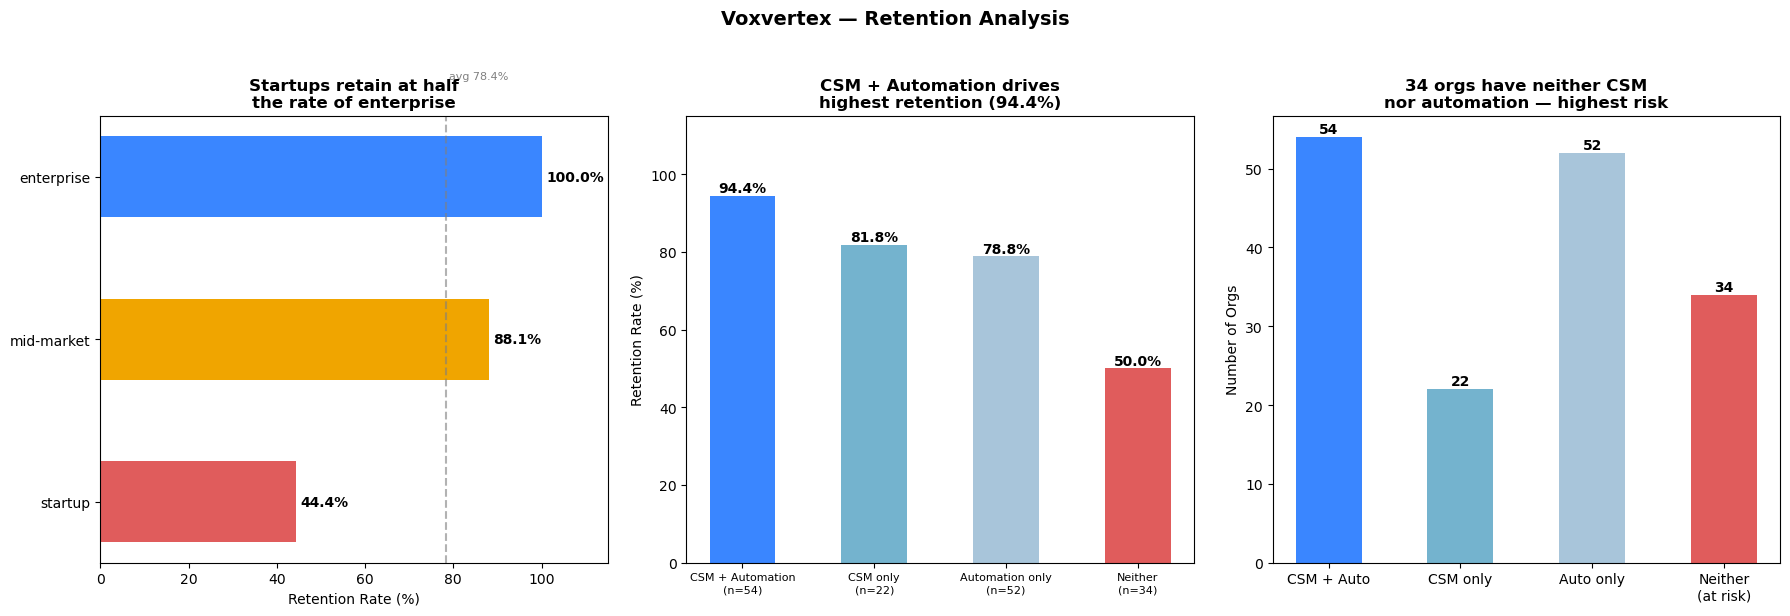

Charts saved.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Voxvertex — Retention Analysis', fontsize=14, fontweight='bold', y=1.02)

# ── Chart 1: Retention by org size ──
sizes = ['startup', 'mid-market', 'enterprise']
rates = [44.4, 88.1, 100.0]
colors = ['#e05c5c', '#f0a500', '#3a86ff']
bars = axes[0].barh(sizes, rates, color=colors, height=0.5)
axes[0].set_xlim(0, 115)
axes[0].set_xlabel('Retention Rate (%)')
axes[0].set_title('Startups retain at half\nthe rate of enterprise', fontweight='bold')
for bar, rate in zip(bars, rates):
    axes[0].text(rate + 1, bar.get_y() + bar.get_height()/2,
                f'{rate}%', va='center', fontweight='bold')
axes[0].axvline(x=78.4, color='gray', linestyle='--', alpha=0.6)
axes[0].text(79, 2.6, 'avg 78.4%', color='gray', fontsize=8)

# ── Chart 2: CSM x Automation 2x2 ──
labels = ['CSM + Automation\n(n=54)', 'CSM only\n(n=22)', 'Automation only\n(n=52)', 'Neither\n(n=34)']
values = [94.4, 81.8, 78.8, 50.0]
bar_colors = ['#3a86ff', '#74b3ce', '#a8c5da', '#e05c5c']
bars2 = axes[1].bar(labels, values, color=bar_colors, width=0.5)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel('Retention Rate (%)')
axes[1].set_title('CSM + Automation drives\nhighest retention (94.4%)', fontweight='bold')
for bar, val in zip(bars2, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1,
                f'{val}%', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', labelsize=8)

# ── Chart 3: 34 orgs with neither — the risk segment ──
segments = ['CSM + Auto', 'CSM only', 'Auto only', 'Neither\n(at risk)']
counts = [54, 22, 52, 34]
bar_colors3 = ['#3a86ff', '#74b3ce', '#a8c5da', '#e05c5c']
bars3 = axes[2].bar(segments, counts, color=bar_colors3, width=0.5)
axes[2].set_ylabel('Number of Orgs')
axes[2].set_title('34 orgs have neither CSM\nnor automation — highest risk', fontweight='bold')
for bar, count in zip(bars3, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, count + 0.5,
                str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('voxvertex_retention_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved.")